# 🛒 Retail Sales Analysis
## Notebook 3 — Exploratory Data Analysis (EDA)

**Цель:** изучить ключевые метрики бизнеса, сезонность, топ-категории и товары, поведение клиентов.

---
## 1. Импорт и загрузка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
sns.set_theme(style='whitegrid', palette='muted')
PALETTE = 'Blues_d'

print('✅ Библиотеки загружены')

✅ Библиотеки загружены


In [2]:
df               = pd.read_csv('df_merged.csv', parse_dates=['SalesDate'])
checks           = pd.read_csv('checks.csv',    parse_dates=['check_date'])
product_features = pd.read_csv('product_features.csv')

print(f'df:               {df.shape}')
print(f'checks:           {checks.shape}')
print(f'product_features: {product_features.shape}')

df:               (6690599, 33)
checks:           (6690599, 10)
product_features: (452, 9)


---
## 2. Общие метрики бизнеса

In [3]:
total_revenue      = df['Revenue'].sum()
total_customers    = df['CustomerID'].nunique()
total_transactions = df['TransactionNumber'].nunique()
total_products     = df['ProductID'].nunique()
avg_check          = checks['check_revenue'].mean()
date_range         = f"{df['SalesDate'].min().date()} → {df['SalesDate'].max().date()}"

print('=' * 50)
print(f'  Общая выручка:          {total_revenue:>15,.2f}')
print(f'  Уникальных клиентов:    {total_customers:>15,}')
print(f'  Уникальных транзакций:  {total_transactions:>15,}')
print(f'  Уникальных товаров:     {total_products:>15,}')
print(f'  Средний чек:            {avg_check:>15,.2f}')
print(f'  Период данных:          {date_range}')
print('=' * 50)

  Общая выручка:          4,289,241,827.19
  Уникальных клиентов:             98,759
  Уникальных транзакций:        6,690,599
  Уникальных товаров:                 452
  Средний чек:                     641.08
  Период данных:          2018-01-01 → 2018-05-09


---
## 3. Продажи по месяцам

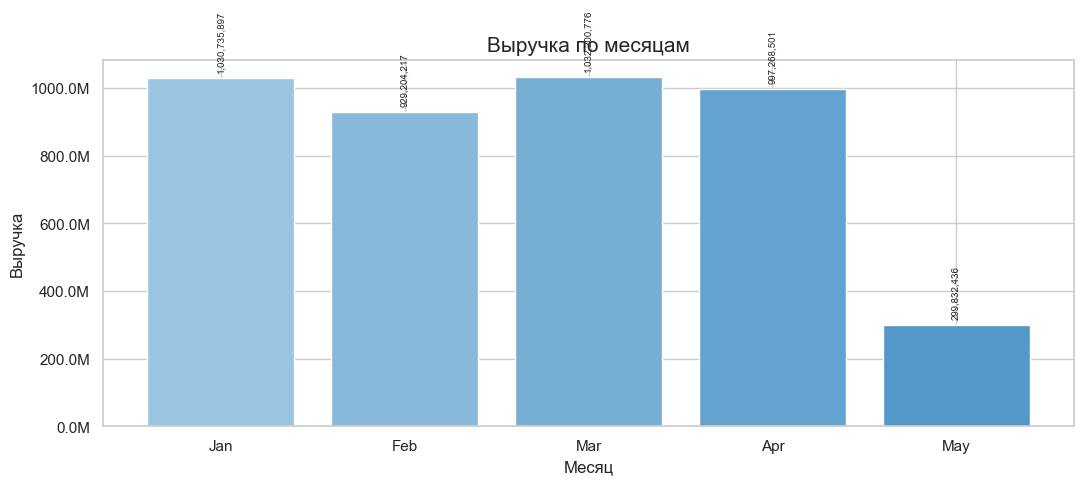

Самый прибыльный месяц: Mar  (1,032,200,775.73)


In [7]:
MONTH_NAMES = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May'}

monthly_sales = (
    df.groupby('month')['Revenue']
    .sum()
    .rename(index=MONTH_NAMES)
)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(monthly_sales.index, monthly_sales.values,
              color=sns.color_palette(PALETTE, 12))
ax.bar_label(bars, fmt='{:,.0f}', rotation=90, padding=4, fontsize=7)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.set_title('Выручка по месяцам', fontsize=15)
ax.set_xlabel('Месяц')
ax.set_ylabel('Выручка')
plt.tight_layout()
plt.show()

best_month = monthly_sales.idxmax()
print(f'Самый прибыльный месяц: {best_month}  ({monthly_sales[best_month]:,.2f})')

---
## 6. Топ-10 категорий по выручке

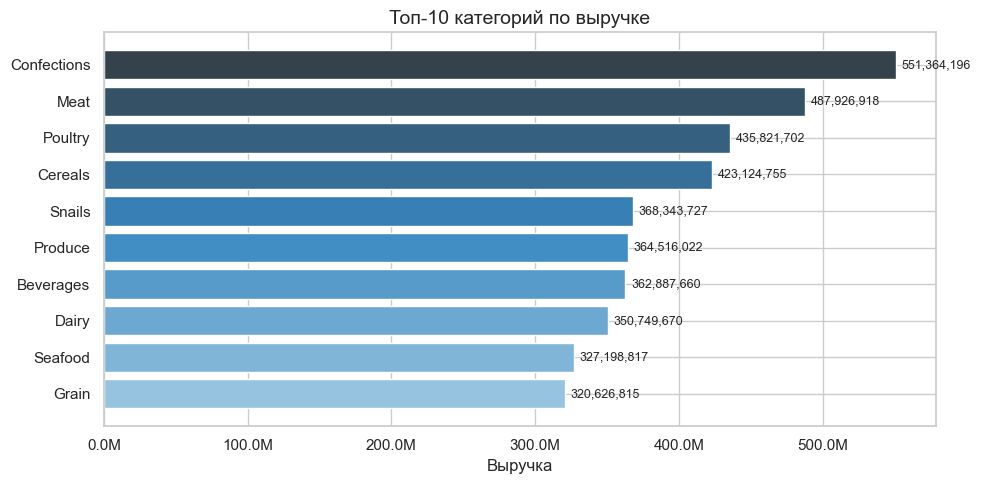

Самая прибыльная категория: Confections


In [12]:
category_sales = (
    df.groupby('CategoryName')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(category_sales.index[::-1], category_sales.values[::-1],
               color=sns.color_palette(PALETTE, 10))
ax.bar_label(bars, fmt='{:,.0f}', padding=4, fontsize=9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.set_title('Топ-10 категорий по выручке', fontsize=14)
ax.set_xlabel('Выручка')
plt.tight_layout()
plt.show()

top_category = category_sales.idxmax()
print(f'Самая прибыльная категория: {top_category}')

---
## 7. Топ-10 товаров по выручке

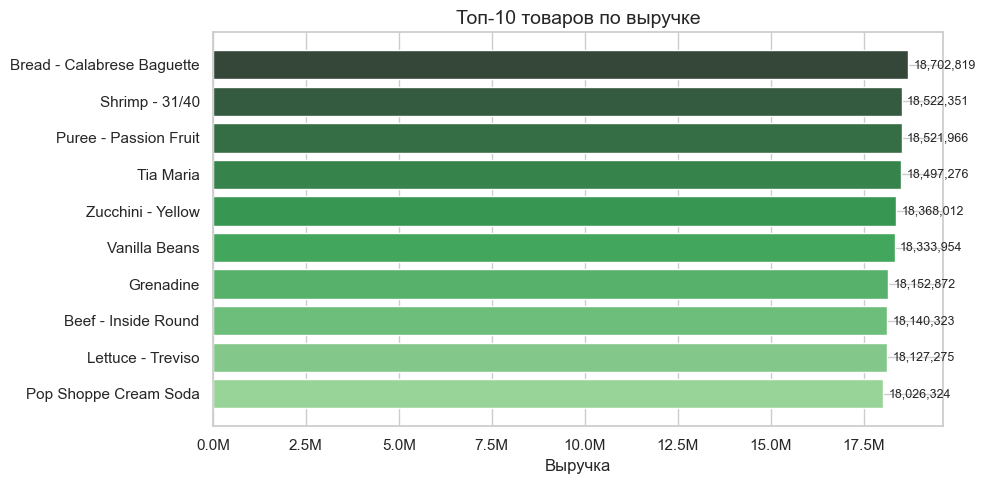

,product_name,category,price,total_quantity_sold,total_revenue,num_customers
0,Bread - Calabrese Baguette,Dairy,98.60,195509,18702819.49,13870
1,Shrimp - 31/40,Cereals,99.88,191156,18522350.93,13682
2,Puree - Passion Fruit,Beverages,98.83,193038,18521965.85,13789
3,Tia Maria,Beverages,98.25,194227,18497276.26,13861
4,Zucchini - Yellow,Snails,98.46,192274,18368011.96,13703
5,Vanilla Beans,Poultry,97.84,193200,18333954.17,13811
6,Grenadine,Grain,96.39,194128,18152871.70,13833
7,Beef - Inside Round,Meat,99.32,188671,18140322.53,13623
8,Lettuce - Treviso,Cereals,96.41,193861,18127274.82,13844
9,Pop Shoppe Cream Soda,Dairy,95.74,194035,18026323.89,13897


In [13]:
top_products = product_features.sort_values('total_revenue', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_products['product_name'][::-1], top_products['total_revenue'][::-1],
               color=sns.color_palette('Greens_d', 10))
ax.bar_label(bars, fmt='{:,.0f}', padding=4, fontsize=9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.set_title('Топ-10 товаров по выручке', fontsize=14)
ax.set_xlabel('Выручка')
plt.tight_layout()
plt.show()

display(top_products[['product_name', 'category', 'price', 'total_quantity_sold',
                       'total_revenue', 'num_customers']].reset_index(drop=True))

---
## 8. Анализ среднего чека

Статистика по чекам:


count   6690599.00
mean        641.08
std         547.08
min           0.04
25%         180.65
50%         490.77
75%         983.74
max        2496.89
Name: check_revenue, dtype: float64

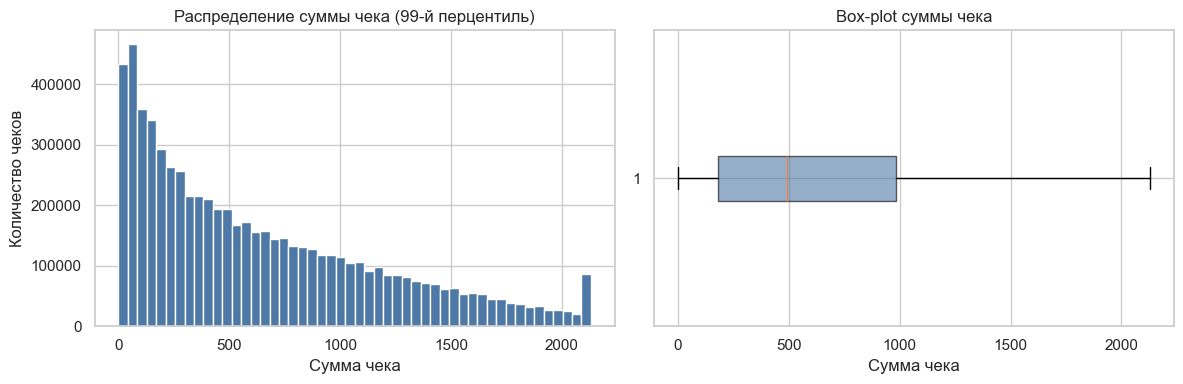

In [14]:
print('Статистика по чекам:')
display(checks['check_revenue'].describe().rename('check_revenue'))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Гистограмма
axes[0].hist(checks['check_revenue'].clip(upper=checks['check_revenue'].quantile(0.99)),
             bins=50, color='#4e79a7', edgecolor='white')
axes[0].set_title('Распределение суммы чека (99-й перцентиль)', fontsize=12)
axes[0].set_xlabel('Сумма чека')
axes[0].set_ylabel('Количество чеков')

# Box-plot
axes[1].boxplot(checks['check_revenue'].clip(upper=checks['check_revenue'].quantile(0.99)),
                vert=False, patch_artist=True,
                boxprops=dict(facecolor='#4e79a7', alpha=0.6))
axes[1].set_title('Box-plot суммы чека', fontsize=12)
axes[1].set_xlabel('Сумма чека')

plt.tight_layout()
plt.show()

---
## 9. Активность по дням недели

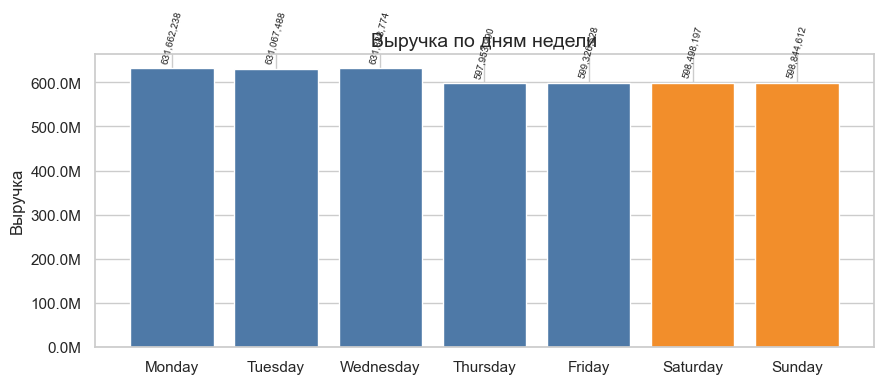

In [15]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_revenue = df.groupby('day_of_week')['Revenue'].sum().reindex(day_order)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(day_order, day_revenue.values,
              color=['#f28e2b' if d in ['Saturday','Sunday'] else '#4e79a7' for d in day_order])
ax.bar_label(bars, fmt='{:,.0f}', rotation=75, padding=3, fontsize=7)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.set_title('Выручка по дням недели', fontsize=14)
ax.set_ylabel('Выручка')
plt.tight_layout()
plt.show()